# Minimal Smoothed-RHO / Hard-Rule Trajectory

This notebook builds a small Gaussian experiment from the current `aexgym` framework, defines a local active-set rule based on empirical means with a protected baseline arm, and executes a trajectory where RHO optimizes with a smoothed rule while the actual experiment applies the hard version of the same rule.

The local rule drops an arm when both conditions hold:

- the arm's effective sample size is at least `min_n_eff`, and
- the empirical mean of the guardrail metric is below `floor`, unless the arm is the protected `baseline_arm_idx`.

Set `rho_active_beta` to a finite positive value for smooth optimization. The actual rollout below uses `SmoothingConfig(beta=math.inf)`, which produces exact 0/1 active weights.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import math
import torch

from aexgym.core import ActiveSetDecision, GaussianMetricModel, SmoothingConfig
from aexgym.experiments.revision.plotting import plot_two_metric_trajectory
from aexgym.policies import (
    BasePlusResidualLogitParameterization,
    PathwiseActiveSetRhoSimulation,
    RhoPolicy,
    TemporalUniformityRegularizer,
)

torch.set_printoptions(precision=4, sci_mode=False)

## Define The Empirical-Mean Rule

This is a deliberately simple rule for inspection. It uses only the current information-form state: `state.n_eff` and `model.empirical_mean(state)`. Arm `baseline_arm_idx` is protected and cannot be eliminated, so the rule does not need separate nonempty-set recovery logic. The same `evaluate(...)` method supports both hard and smooth decisions.

In [3]:
class EmpiricalMeanDropRule:
    def __init__(self, floor, min_n_eff, guardrail_metric_idx, baseline_arm_idx):
        self.guardrail_metric_idx = int(guardrail_metric_idx)
        self.floor = float(floor)
        self.min_n_eff = float(min_n_eff)
        self.baseline_arm_idx = int(baseline_arm_idx)

    def evaluate(self, state, model, *, smoothing=None):
        smoothing = smoothing or SmoothingConfig()
        empirical_mean = model.empirical_mean(state)[:, self.guardrail_metric_idx]
        sampled_enough_score = state.n_eff - self.min_n_eff
        bad_mean_score = self.floor - empirical_mean
        can_drop = torch.ones(state.n_arms, dtype=torch.bool, device=state.device)
        can_drop[self.baseline_arm_idx] = False

        if smoothing.hard:
            drop = (sampled_enough_score >= 0) & (bad_mean_score > 0) & (state.active > 0) & can_drop
            next_active = torch.where(drop, torch.zeros_like(state.active), state.active)
            drop_weight = drop.to(dtype=state.dtype)
        else:
            beta = float(smoothing.beta)
            sampled_enough = torch.sigmoid(beta * sampled_enough_score)
            bad_mean = torch.sigmoid(beta * bad_mean_score)
            drop_weight = sampled_enough * bad_mean * can_drop.to(dtype=state.dtype)
            survival = 1.0 - drop_weight
            next_active = state.active * survival
            next_active = next_active.clone()
            next_active[self.baseline_arm_idx] = state.active[self.baseline_arm_idx]

        return ActiveSetDecision(
            active=next_active,
            diagnostics={
                "empirical_mean": empirical_mean.detach().cpu().tolist(),
                "n_eff": state.n_eff.detach().cpu().tolist(),
                "drop_weight": drop_weight.detach().cpu().tolist(),
            },
        )

## Build A Minimal Environment

This is a four-arm, two-metric Gaussian experiment. Arms 1 and 3 have negative true effects and should become candidates for pruning once they receive enough effective sample size.

In [4]:
K = 4
J = 2
batch_sizes = torch.tensor([10.0, 25.0, 50.0, 100.0], dtype=torch.float64)

true_theta = torch.tensor([
    [0.02, 1.0],
    [-0.18, 1.0],
    [0.16, -10.0], 
    [-0.08, 1.0]],
    dtype=torch.float64)

prior_mean = torch.zeros(K, J, dtype=torch.float64)
prior_cov = torch.eye(J, dtype=torch.float64).repeat(K, 1, 1) * 0.20
obs_cov = torch.eye(J, dtype=torch.float64).repeat(K, 1, 1) * 1.00

model = GaussianMetricModel(
    prior_mean=prior_mean,
    prior_cov=prior_cov,
    obs_cov=obs_cov,
    target_metric_idx=0,
    batch_sizes=batch_sizes,
)

rule = EmpiricalMeanDropRule(
    floor=-1.0,
    min_n_eff=1.0,
    guardrail_metric_idx=1,
    baseline_arm_idx=0,
)
state = model.initial_state()

print("true theta (all arms, all metrics):")
print(true_theta)
print("initial posterior mean (all arms, all metrics):")
print(model.posterior_mean(state))
print("initial posterior covariance (per-arm metric covariance):")
print(model.posterior_cov(state))
print("initial active weights:", state.active)

true theta (all arms, all metrics):
tensor([[  0.0200,   1.0000],
        [ -0.1800,   1.0000],
        [  0.1600, -10.0000],
        [ -0.0800,   1.0000]], dtype=torch.float64)
initial posterior mean (all arms, all metrics):
tensor([[0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.]], dtype=torch.float64)
initial posterior covariance (per-arm metric covariance):
tensor([[[0.2000, -0.0000],
         [-0.0000, 0.2000]],

        [[0.2000, -0.0000],
         [-0.0000, 0.2000]],

        [[0.2000, -0.0000],
         [-0.0000, 0.2000]],

        [[0.2000, -0.0000],
         [-0.0000, 0.2000]]], dtype=torch.float64)
initial active weights: tensor([1., 1., 1., 1.], dtype=torch.float64)


## Configure RHO

`PathwiseActiveSetRhoSimulation(rule)` uses the same rule object as the hard rollout. RHO gets a finite `active_beta`, so its inner optimization sees smooth active weights. `rho_optimization_seed` controls only the Monte Carlo draws used inside RHO optimization. The actual trajectory below applies `beta=inf` after each observed batch.

In [5]:
active_beta = 8.0
rho_optimization_seed = 2026

rho = RhoPolicy(
    simulator=PathwiseActiveSetRhoSimulation(rule),
    parameterization=BasePlusResidualLogitParameterization(),
    regularizer=TemporalUniformityRegularizer(weight=50.0),
    epochs=50,
    lr=0.01,
    num_samples=128,
    active_beta=active_beta,
    terminal_beta=20.0,
    optimization_seed=rho_optimization_seed,
    name="smoothed_rho",
)
rho.reset(0)

## Execute One Trajectory

At each stage:

1. RHO solves the residual-horizon problem using the smoothed version of `rule`.
2. We execute only the first allocation.
3. The model updates in information form.
4. The hard version of the same rule updates the actual active set.

In [6]:
obs_generator = torch.Generator().manual_seed(123)
records = []

state = model.initial_state()
trajectory_states = [state]
trajectory_allocations = []
rho_optimization_histories = []
rho_planned_sequences = []
for _ in range(model.horizon):
    stage = state.t
    smooth_rule_before_observation = rule.evaluate(state, model, smoothing=SmoothingConfig(beta=active_beta))
    hard_rule_before_observation = rule.evaluate(state, model, smoothing=SmoothingConfig(beta=math.inf))

    allocation = rho.allocate(state, model)
    trajectory_allocations.append(allocation.detach().clone())
    rho_optimization_histories.append([dict(step) for step in rho.last_plan.optimization_trace])
    rho_planned_sequences.append(rho.last_plan.sequence.detach().clone())
    observation = model.sample_observation(true_theta, allocation, state, generator=obs_generator)
    updated = model.update(state, allocation, observation)

    smooth_rule_after_observation = rule.evaluate(updated, model, smoothing=SmoothingConfig(beta=active_beta))
    hard_rule_after_observation = rule.evaluate(updated, model, smoothing=SmoothingConfig(beta=math.inf))

    next_state = updated.replace(
        active=hard_rule_after_observation.active,
    )

    records.append(
        {
            "stage": stage,
            "batch_size": float(model.batch_size(stage).item()),
            "allocation": allocation.detach().cpu().tolist(),
            "observation": observation.detach().cpu().tolist(),
            "n_eff_after": updated.n_eff.detach().cpu().tolist(),
            "empirical_mean_after": model.empirical_mean(updated).detach().cpu().tolist(),
            "posterior_mean_after": model.posterior_mean(updated).detach().cpu().tolist(),
            "posterior_cov_after": model.posterior_cov(updated).detach().cpu().tolist(),
            "smooth_active_before": smooth_rule_before_observation.active.detach().cpu().tolist(),
            "hard_active_before": hard_rule_before_observation.active.detach().cpu().tolist(),
            "smooth_active_after": smooth_rule_after_observation.active.detach().cpu().tolist(),
            "hard_active_after": hard_rule_after_observation.active.detach().cpu().tolist(),
            "hard_drop_weight_after": hard_rule_after_observation.diagnostics["drop_weight"],
            "rho_objective": rho.last_plan.objective_value,
            "rho_smoothed_value": rho.last_plan.simulation_value,
            "rho_hard_value_same_plan": rho.last_plan.hard_simulation_value,
            "rho_optimization_epochs": len(rho.last_plan.optimization_trace),
            "rho_initial_loss": rho.last_plan.optimization_trace[0]["loss"] if rho.last_plan.optimization_trace else None,
            "rho_final_training_loss": rho.last_plan.optimization_trace[-1]["loss"] if rho.last_plan.optimization_trace else None,
        }
    )
    state = next_state
    trajectory_states.append(state)

print("selected arm:", model.selected_arm(state))
print("final active:", state.active)
print("completed stages:", state.t)

selected arm: 0
final active: tensor([1., 1., 0., 1.], dtype=torch.float64)
completed stages: 4


In [7]:
tensor_fields = {
    "allocation",
    "observation",
    "n_eff_after",
    "empirical_mean_after",
    "posterior_mean_after",
    "posterior_cov_after",
    "smooth_active_before",
    "hard_active_before",
    "smooth_active_after",
    "hard_active_after",
    "hard_drop_weight_after",
}

for record in records:
    print("\n--- stage", record["stage"], "---")
    for key, value in record.items():
        if key == "stage":
            continue
        if key in tensor_fields:
            print(f"{key}:")
            print(torch.tensor(value, dtype=torch.float64))
        else:
            print(f"{key}: {value}")


--- stage 0 ---
batch_size: 10.0
allocation:
tensor([0.3201, 0.1497, 0.1599, 0.3703], dtype=torch.float64)
observation:
tensor([[-0.0423,  1.0673],
        [-0.4821,  0.8035],
        [-0.7867, -9.8345],
        [-0.5853,  0.6076]], dtype=torch.float64)
n_eff_after:
tensor([3.2014, 1.4974, 1.5986, 3.7026], dtype=torch.float64)
empirical_mean_after:
tensor([[-0.0423,  1.0673],
        [-0.4821,  0.8035],
        [-0.7867, -9.8345],
        [-0.5853,  0.6076]], dtype=torch.float64)
posterior_mean_after:
tensor([[-0.0165,  0.4166],
        [-0.1111,  0.1852],
        [-0.1906, -2.3825],
        [-0.2490,  0.2585]], dtype=torch.float64)
posterior_cov_after:
tensor([[[0.1219, -0.0000],
         [-0.0000, 0.1219]],

        [[0.1539, -0.0000],
         [-0.0000, 0.1539]],

        [[0.1515, -0.0000],
         [-0.0000, 0.1515]],

        [[0.1149, -0.0000],
         [-0.0000, 0.1149]]], dtype=torch.float64)
smooth_active_before:
tensor([1.0000, 1.0000, 1.0000, 1.0000], dtype=torch.float64)


## Optional: Inspect The Final RHO Plan

After each call to `rho.allocate(...)`, `rho.last_plan.sequence` stores the optimized proposal sequence for the remaining horizon. The actual allocation executed at that stage is only the first row, projected through the current hard active set.

In [8]:
print("last optimized proposal sequence:")
print(rho.last_plan.sequence)
print("last first allocation:")
print(rho.last_plan.first_allocation)
print("last base allocation:")
print(rho.last_plan.base_allocation)
print("last residual sequence:")
print(rho.last_plan.residual_sequence)

last optimized proposal sequence:
tensor([[0.2279, 0.4397, 0.0000, 0.3324]], dtype=torch.float64)
last first allocation:
tensor([0.2279, 0.4397, 0.0000, 0.3324], dtype=torch.float64)
last base allocation:
tensor([0.2279, 0.4397, 0.0000, 0.3324], dtype=torch.float64)
last residual sequence:
tensor([[0., 0., 0., 0.]], dtype=torch.float64)


## Plot The Trajectory

Columns are arms, followed by RHO loss and RHO plan columns. Stage rows show the two-metric posterior belief ellipse, posterior mean, empirical mean, effective sample size, and active weight. Transition rows show the executed allocation mass for each arm. The RHO loss plot uses the configured training duration on the x axis, so early stopping would appear as a shorter curve. The RHO plan plot shows planned remaining-stage samples by active arm, stacked with the next stage on the bottom.

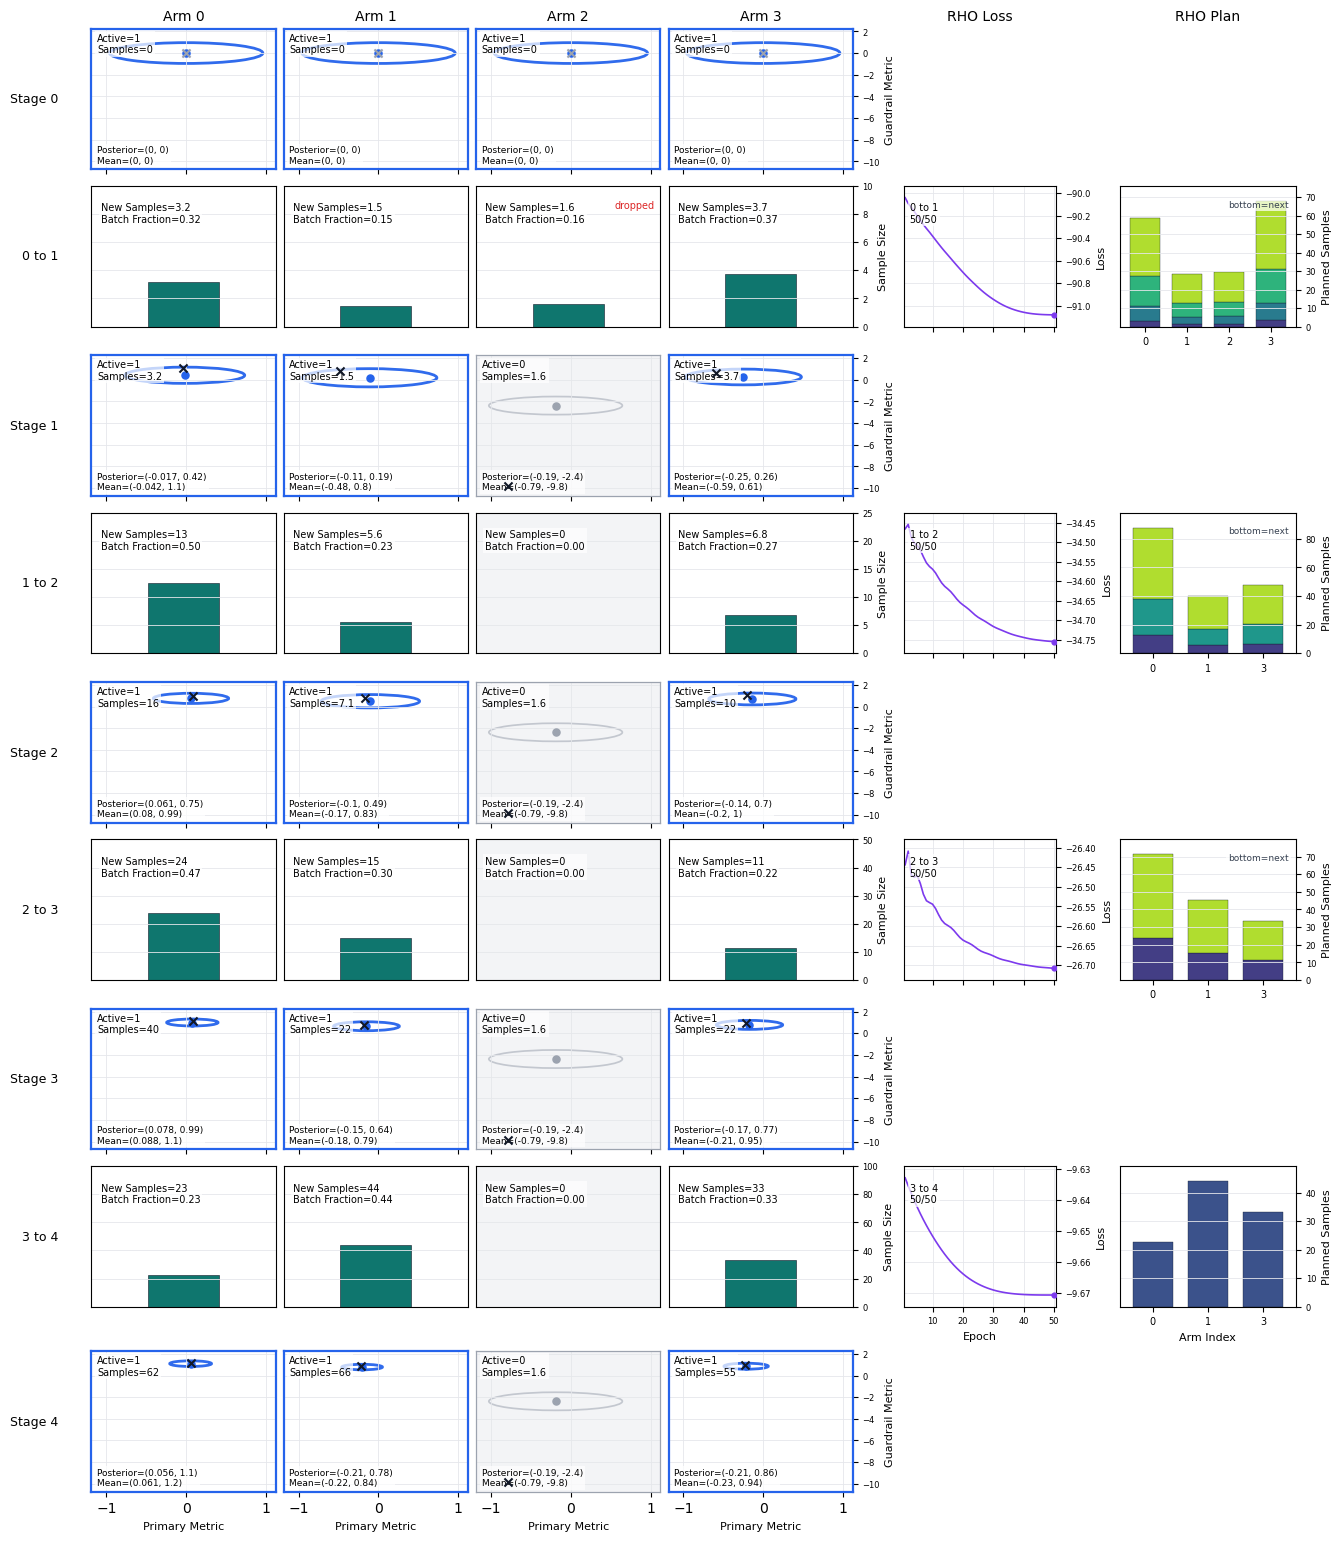

In [11]:
fig, axes = plot_two_metric_trajectory(
    model,
    states=trajectory_states,
    allocations=trajectory_allocations,
    metric_names=("Primary Metric", "Guardrail Metric"),
    optimization_histories=rho_optimization_histories,
    optimization_max_epochs=rho.epochs,
    planned_sequences=rho_planned_sequences,
)